# 🔹 Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vaibh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vaibh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Loading Data

In [5]:
df = pd.read_csv("sentiment_analysis.csv")
df.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


# 🔹 Initial Data Inspection

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [8]:
df.describe()

,Year,Month,Day
count,499.000000,499.000000,499.000000
mean,2020.394790,6.084168,15.693387
std,2.830991,3.652711,8.804673
min,2010.000000,1.000000,1.000000
25%,2019.000000,2.000000,8.000000
50%,2021.000000,6.000000,15.000000
75%,2023.000000,9.000000,22.000000
max,2023.000000,12.000000,31.000000


In [9]:
df.columns

Index(['Year', 'Month', 'Day', 'Time of Tweet', 'text', 'sentiment',
       'Platform'],
      dtype='object')

In [10]:
df.isnull().sum()

Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64

In [11]:
df.shape

(499, 7)

# 🔹 Create Proper Date & Time Features

Time-based analysis is critical for customer support:

Peak complaint hours

Daily / monthly trends

In [14]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# 🔹 Sentiment Distribution Analysis (EDA)

Sentiment tells us:

How many customers are unhappy

How serious the support load is

In [17]:
df['sentiment'].value_counts()

sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64

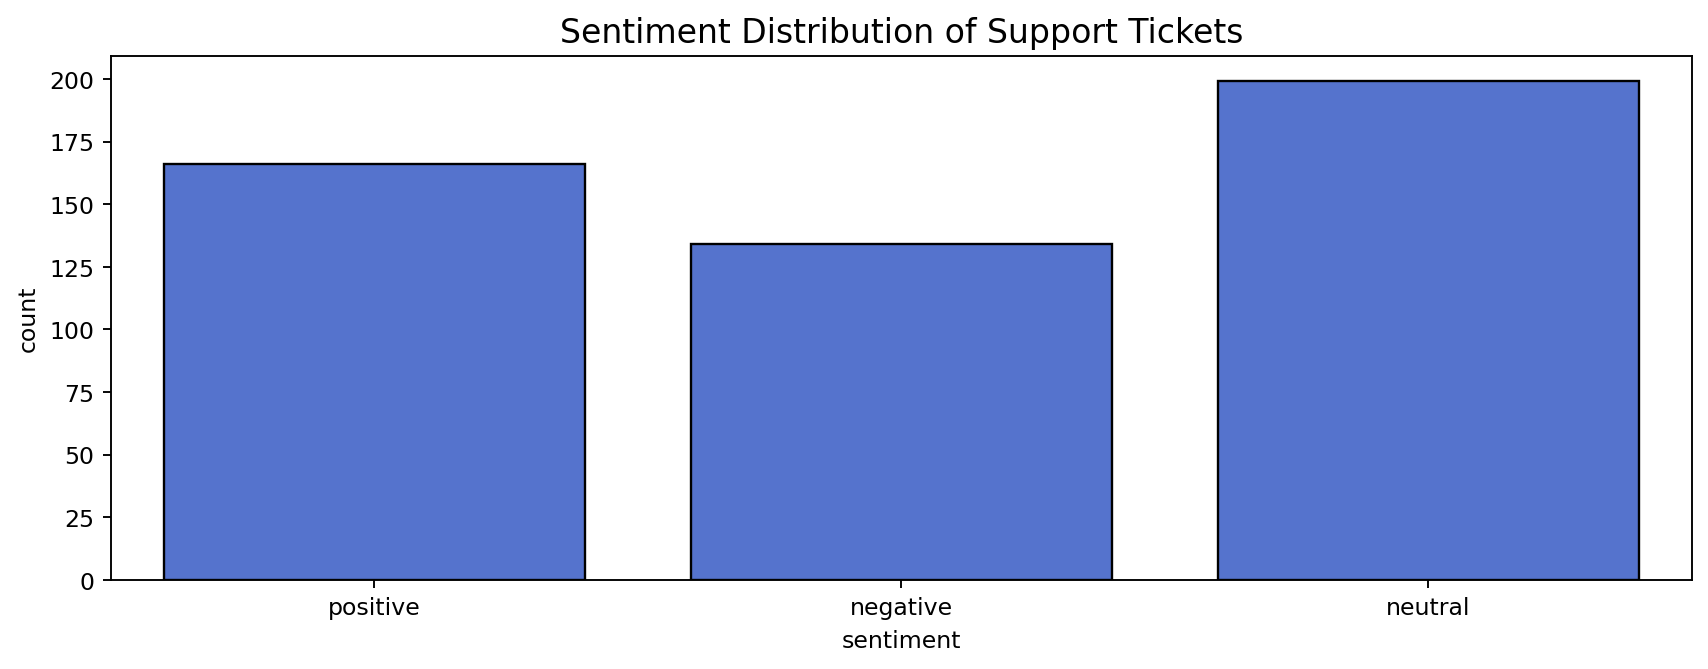

In [27]:
plt.figure(figsize=(12,4), dpi=170)
sns.countplot(x='sentiment', data=df, color='royalblue', ec='k')
plt.title("Sentiment Distribution of Support Tickets", fontsize=14)
plt.show()

# 🔹 Platform-wise Complaint Analysis

Different platforms behave differently:

Twitter users complain more

Mobile users report bugs

In [29]:
pd.crosstab(df['Platform'], df['sentiment'])

sentiment,negative,neutral,positive
Platform,,,
Facebook,52,52,61
Instagram,49,65,57
Twitter,17,35,16
Twitter,14,45,32
Facebook,2,2,0


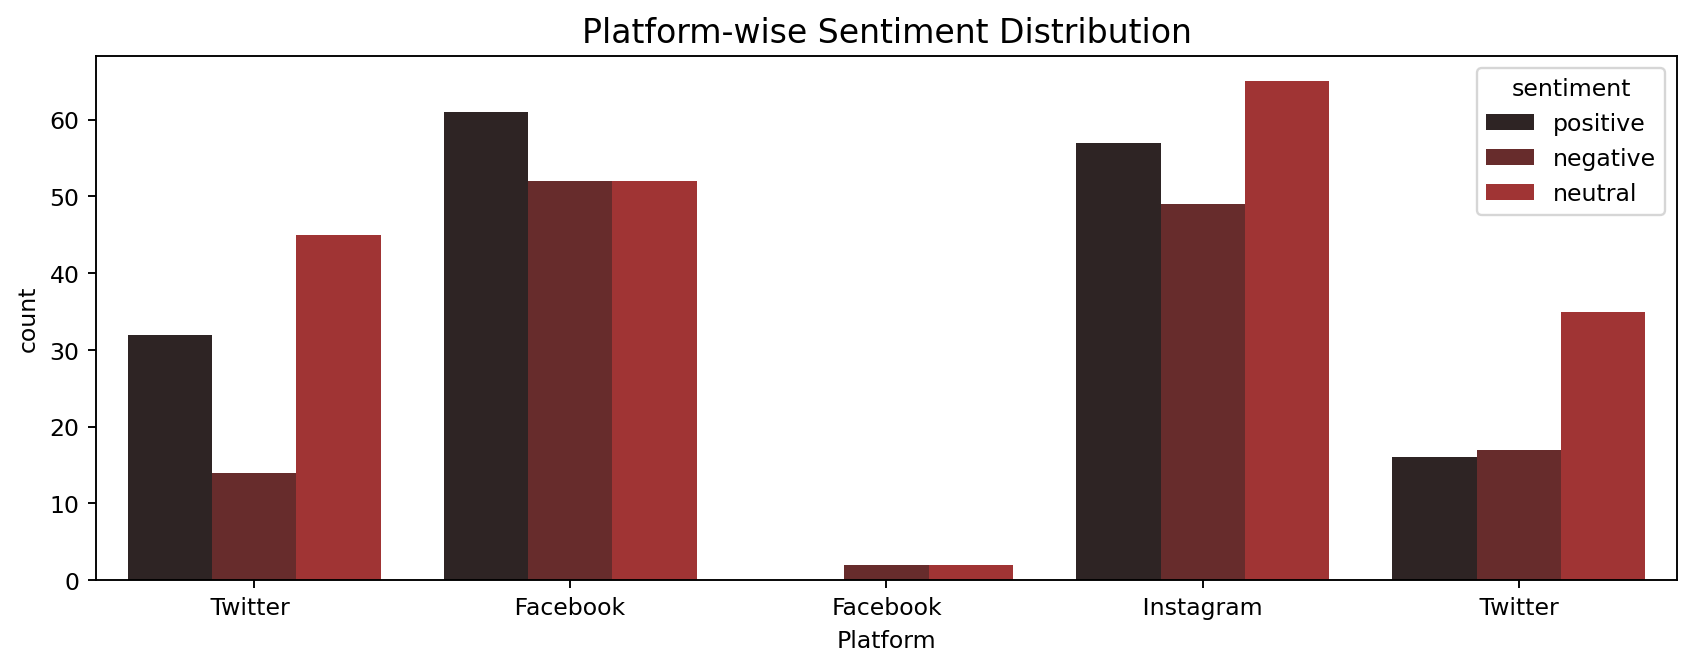

In [39]:
plt.figure(figsize=(12,4), dpi=170)
sns.countplot(x='Platform', hue='sentiment', data=df, palette='dark:firebrick')
plt.title("Platform-wise Sentiment Distribution", fontsize=14)
plt.show()

# 🔹 Text Preprocessing

Raw text contains:

URLs

Emojis

Stopwords

Punctuation
These confuse ML models.

## Import NLP tools

In [28]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [30]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

## Create Text Cleaning Function

In [33]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)        # remove mentions & hashtags
    text = re.sub(r"[^a-z\s]", "", text)         # remove punctuation/numbers
    
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [35]:
df['clean_text'] = df['text'].apply(clean_text)

In [36]:
df[['text', 'clean_text']].head()

,text,clean_text
0,What a great day!!! Looks like dream.,great day look like dream
1,"I feel sorry, I miss you here in the sea beach",feel sorry miss sea beach
2,Don't angry me,dont angry
3,We attend in the class just for listening teac...,attend class listening teacher reading slide n...
4,"Those who want to go, let them go",want go let go


# 🔹 Most Common Complaint Words

Helps identify:

Common issues

Recurring problems

In [39]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()
word_freq = Counter(all_words)

wf = word_freq.most_common(10)
wfq = pd.DataFrame(wf)
wfq

,0,1
0,im,78
1,day,54
2,love,33
3,know,31
4,like,29
5,going,28
6,go,26
7,dont,25
8,happy,24
9,really,22


# 🔹 Analyze Negative Tickets Separately

Negative tickets = high priority support cases

In [45]:
negative_df = df[df['sentiment'] == 'Negative']

In [47]:
neg_words = " ".join(negative_df['clean_text']).split()
Counter(neg_words).most_common(10)

[]

In [49]:
df['Time of Tweet'].unique()

array(['morning', 'noon', 'night'], dtype=object)

In [51]:
df.rename(columns={'Time of Tweet': 'Time_Period'}, inplace=True)

## Time Period Analysis

In [54]:
df['Time_Period'].value_counts()

Time_Period
morning    171
noon       167
night      161
Name: count, dtype: int64

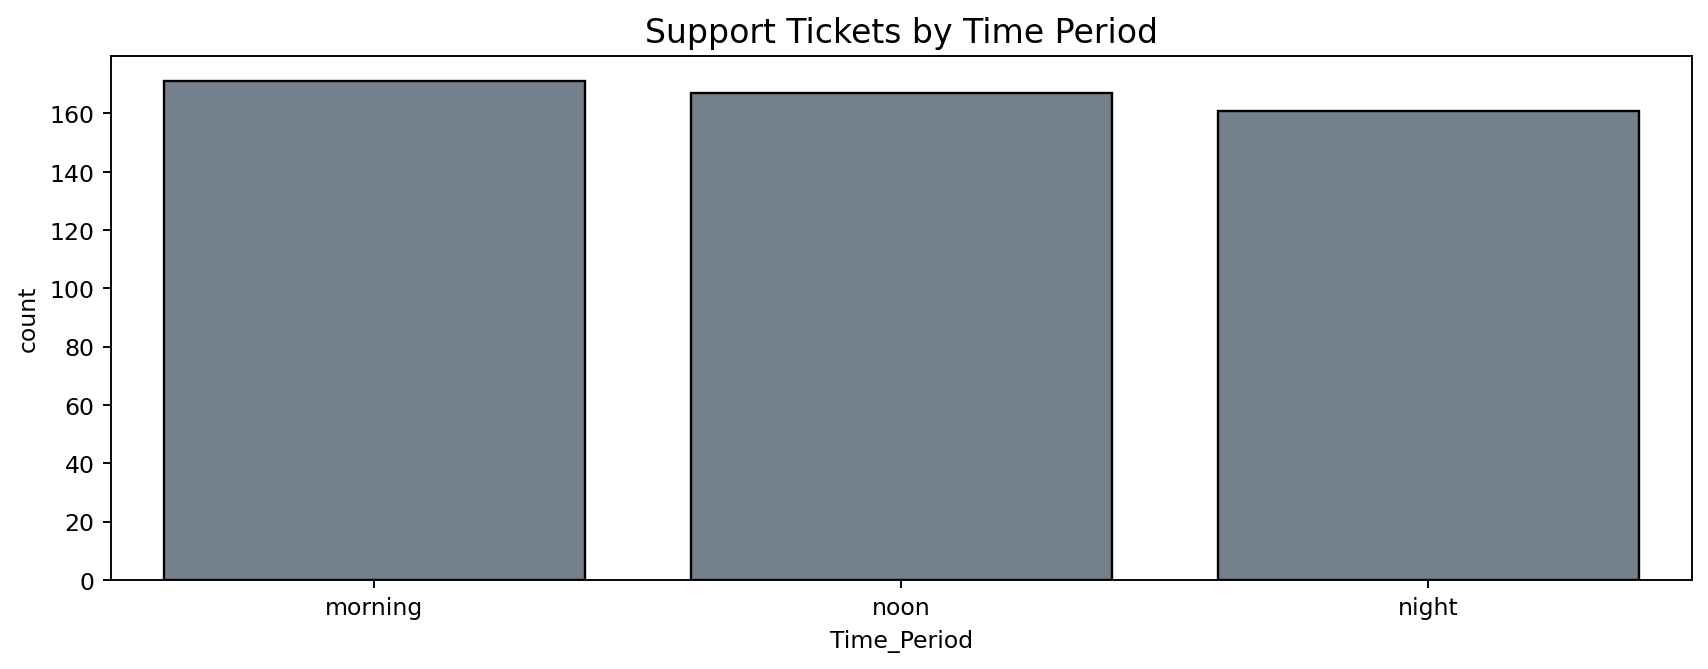

In [115]:
plt.figure(figsize=(12,4), dpi=170)
sns.countplot(x='Time_Period', data=df, color='slategray', ec='k')
plt.title("Support Tickets by Time Period", fontsize=14)
plt.show()

## Sentiment vs Time Period

In [90]:
pd.crosstab(df['Time_Period'], df['sentiment'])

sentiment,negative,neutral,positive
Time_Period,,,
morning,50,65,56
night,51,57,53
noon,33,77,57


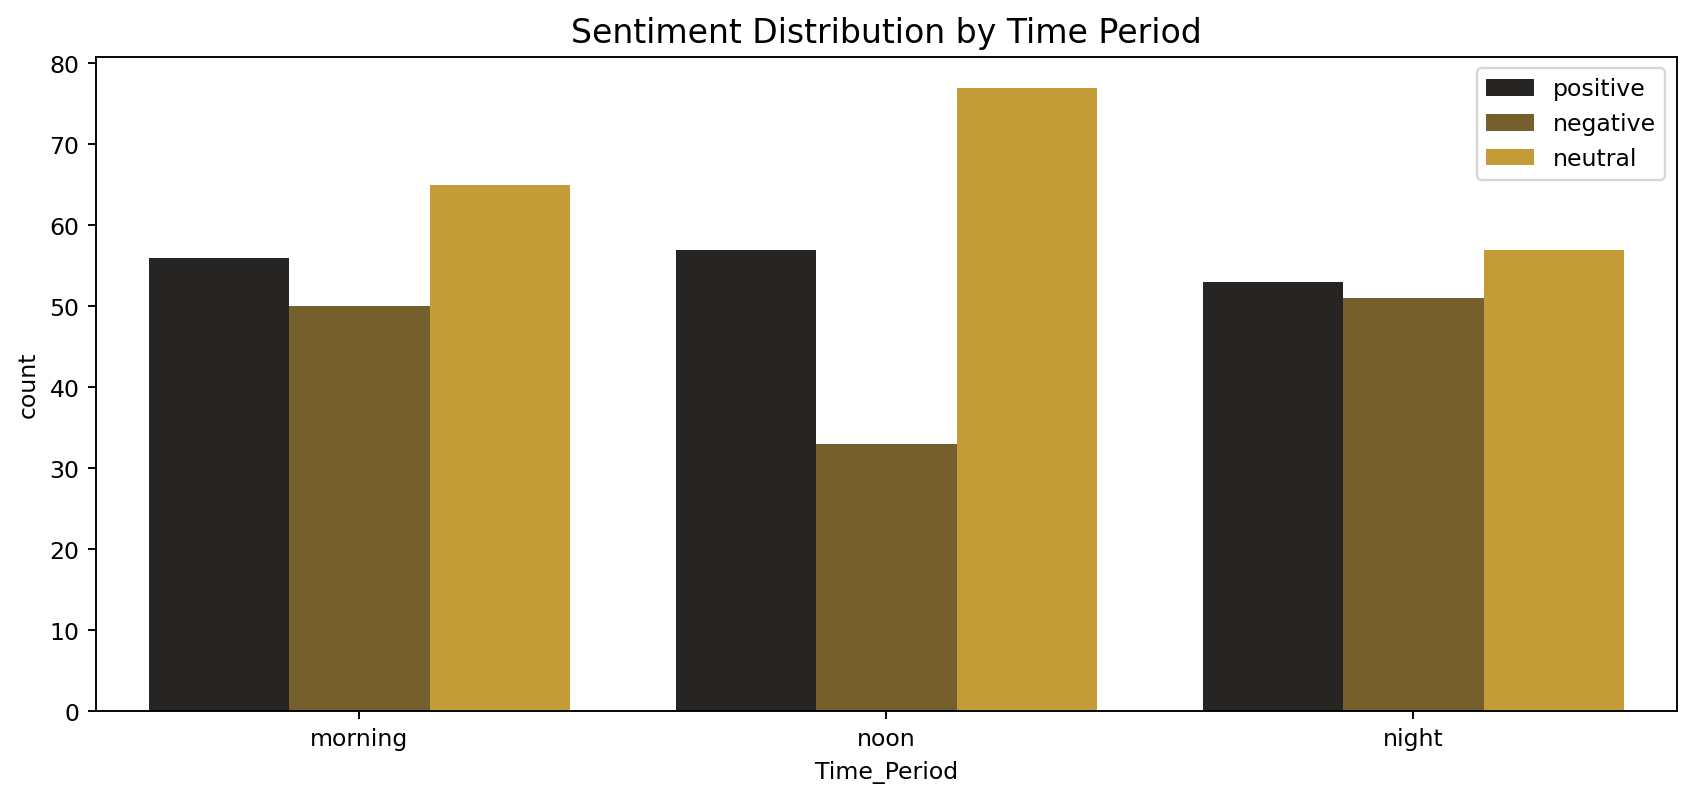

In [125]:
plt.figure(figsize=(12,5), dpi=170)
sns.countplot(x='Time_Period', hue='sentiment', data=df, palette='dark:goldenrod')
plt.title("Sentiment Distribution by Time Period", fontsize=14)
plt.legend(loc='upper right')
plt.show()

## Platform + Time Period Analysis 

In [94]:
pd.crosstab(df['Platform'], df['Time_Period'])

Time_Period,morning,night,noon
Platform,,,
Facebook,85,64,16
Instagram,48,64,59
Twitter,17,11,40
Twitter,21,18,52
Facebook,0,4,0


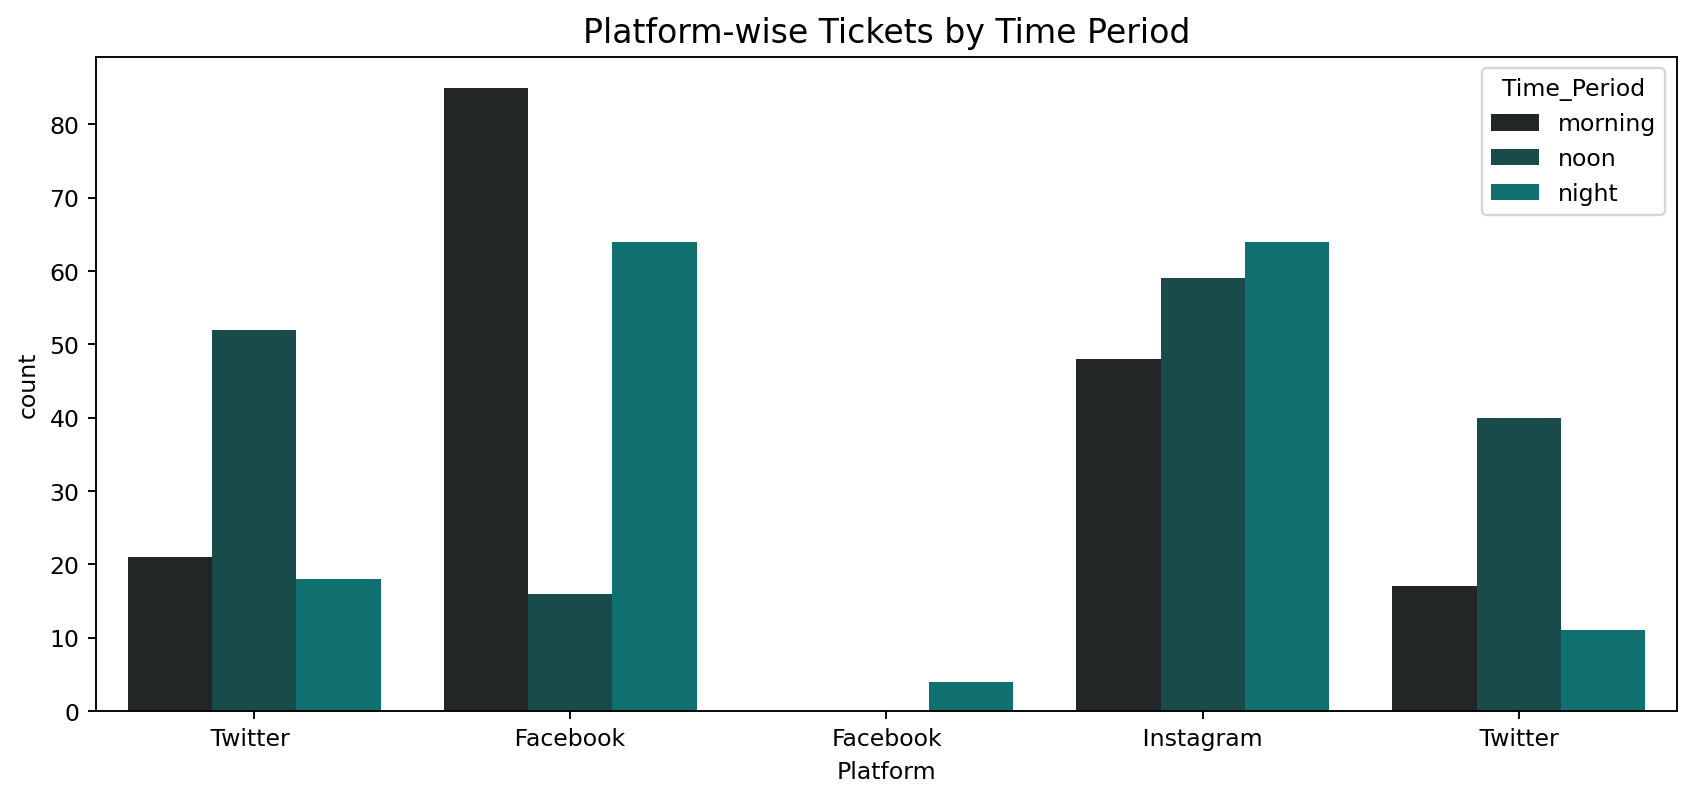

In [129]:
plt.figure(figsize=(12,5), dpi=170)
sns.countplot(x='Platform', hue='Time_Period', data=df, palette='dark:teal')
plt.title("Platform-wise Tickets by Time Period", fontsize=14)
plt.show()

# 🔹 TF-IDF Vectorization

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text'])

# 🤖 MODEL TRAINING & EVALUATION

## 🔹 Prepare Target & Train-Test Split

In [60]:
from sklearn.model_selection import train_test_split

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

stratify=y keeps sentiment distribution balanced.

In [63]:
model_scores = {}

# 1️⃣ Logistic Regression

## 🔹 Model Training

In [67]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 🔹 Prediction & Evaluation

In [70]:
from sklearn.metrics import accuracy_score, classification_report

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
model_scores['Logistic Regression'] = lr_acc

print("Accuracy:", lr_acc)
print(classification_report(y_test, lr_pred))

Accuracy: 0.7
              precision    recall  f1-score   support

    negative       0.77      0.37      0.50        27
     neutral       0.61      0.95      0.75        40
    positive       0.88      0.67      0.76        33

    accuracy                           0.70       100
   macro avg       0.75      0.66      0.67       100
weighted avg       0.74      0.70      0.68       100



# 2️⃣ Naive Bayes

## 🔹 Model Training

In [74]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

## 🔹 Evaluation

In [77]:
nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)
model_scores['Naive Bayes'] = nb_acc

print("Accuracy:", nb_acc)
print(classification_report(y_test, nb_pred))

Accuracy: 0.69
              precision    recall  f1-score   support

    negative       0.89      0.30      0.44        27
     neutral       0.62      0.93      0.74        40
    positive       0.77      0.73      0.75        33

    accuracy                           0.69       100
   macro avg       0.76      0.65      0.64       100
weighted avg       0.74      0.69      0.66       100



# 3️⃣ Support Vector Machine

## 🔹 Model Training

In [81]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

LinearSVC()

## 🔹 Evaluation

In [83]:
svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)
model_scores['SVM'] = svm_acc

print("Accuracy:", svm_acc)
print(classification_report(y_test, svm_pred))

Accuracy: 0.75
              precision    recall  f1-score   support

    negative       0.79      0.41      0.54        27
     neutral       0.71      0.93      0.80        40
    positive       0.79      0.82      0.81        33

    accuracy                           0.75       100
   macro avg       0.76      0.72      0.72       100
weighted avg       0.76      0.75      0.73       100



# 4️⃣ Random Forest Classifier

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [88]:
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
model_scores['Random Forest'] = rf_acc

print("Accuracy:", rf_acc)
print(classification_report(y_test, rf_pred))

Accuracy: 0.65
              precision    recall  f1-score   support

    negative       0.88      0.26      0.40        27
     neutral       0.54      0.95      0.69        40
    positive       0.91      0.61      0.73        33

    accuracy                           0.65       100
   macro avg       0.78      0.61      0.61       100
weighted avg       0.75      0.65      0.62       100



# 5️⃣ K-Nearest Neighbors (KNN)

## 🔹 Model Training

In [91]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

## 🔹 Evaluation

In [93]:
knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
model_scores['KNN'] = knn_acc

print("Accuracy:", knn_acc)
print(classification_report(y_test, knn_pred))

Accuracy: 0.53
              precision    recall  f1-score   support

    negative       0.82      0.33      0.47        27
     neutral       0.48      0.93      0.63        40
    positive       0.58      0.21      0.31        33

    accuracy                           0.53       100
   macro avg       0.63      0.49      0.47       100
weighted avg       0.61      0.53      0.48       100



# 📊 Model Score Comparison Table

In [95]:
score_df = pd.DataFrame({
    'Model': model_scores.keys(),
    'Accuracy': model_scores.values()
}).sort_values(by='Accuracy', ascending=False)

score_df

,Model,Accuracy
2,SVM,0.75
0,Logistic Regression,0.70
1,Naive Bayes,0.69
3,Random Forest,0.65
4,KNN,0.53


# 📈 Model Performance Visualization

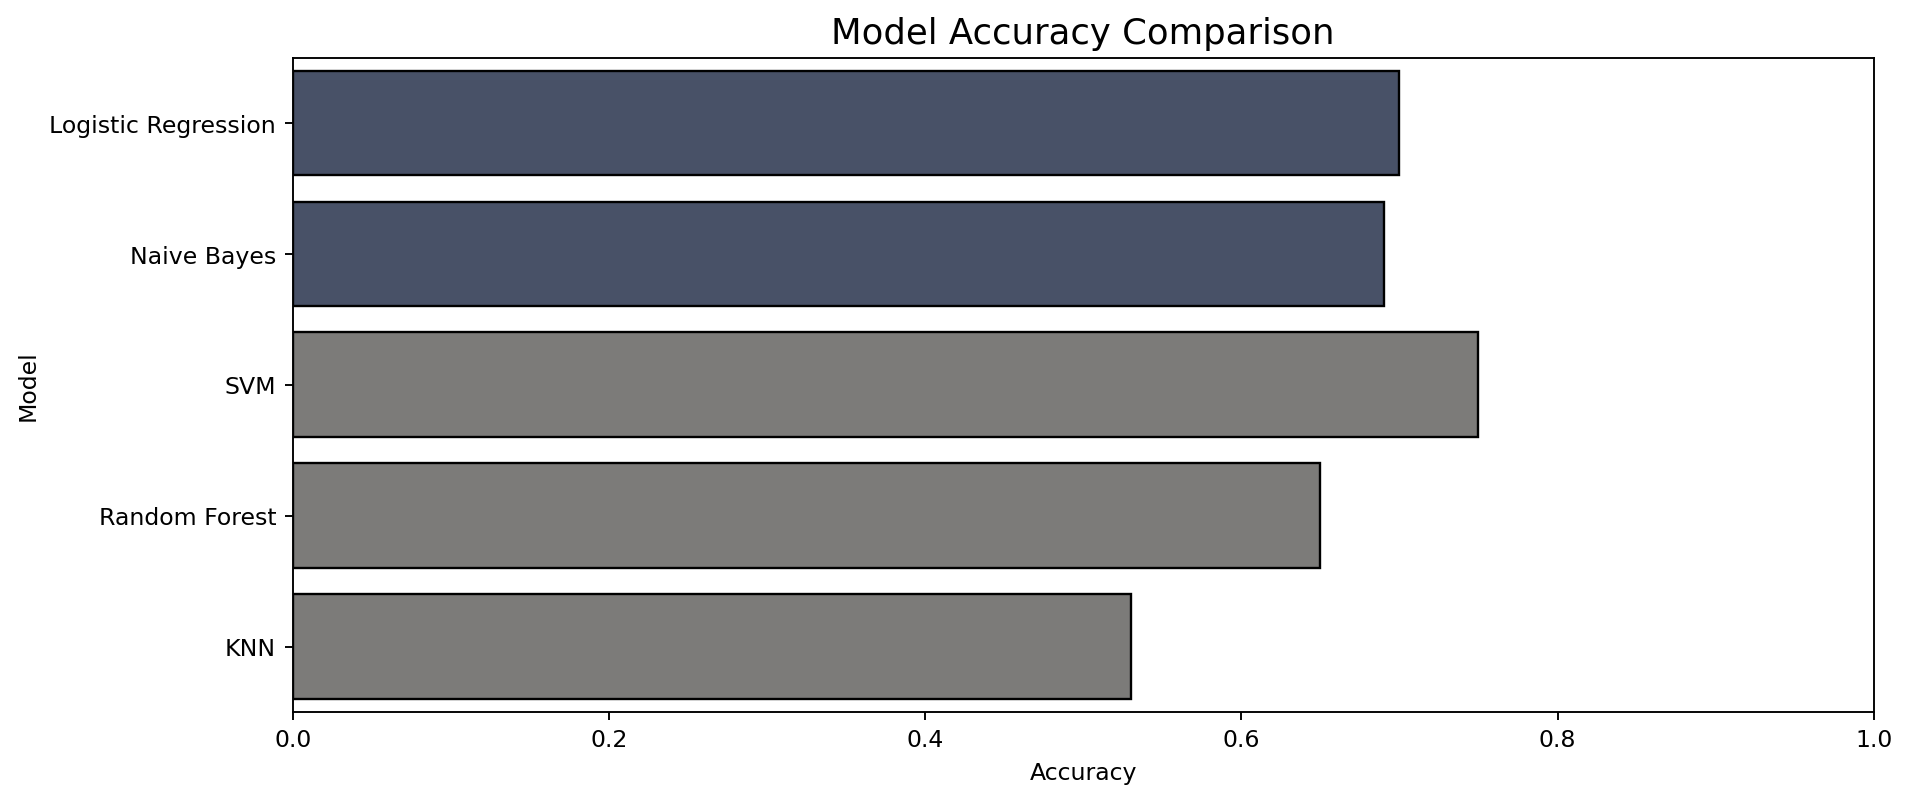

In [216]:
plt.figure(figsize=(12,5), dpi=170)
sns.barplot(x='Accuracy', y='Model', hue=y, data=score_df, palette='cividis', legend=False, ec='k')
plt.title("Model Accuracy Comparison", fontsize=15)
plt.xlim(0,1)
plt.show()

# 📊 CONFUSION MATRIX FOR ALL MODELS

In [103]:
from sklearn.metrics import confusion_matrix

## 1️⃣ Logistic Regression – Confusion Matrix

In [118]:
lr_pred = lr_model.predict(X_test)
cm_lr = confusion_matrix(y_test, lr_pred)
cm_lr

array([[10, 16,  1],
       [ 0, 38,  2],
       [ 3,  8, 22]], dtype=int64)

## 2️⃣ Naive Bayes – Confusion Matrix

In [120]:
nb_pred = nb_model.predict(X_test)
cm_nb = confusion_matrix(y_test, nb_pred)
cm_nb

array([[ 8, 15,  4],
       [ 0, 37,  3],
       [ 1,  8, 24]], dtype=int64)

## 3️⃣ Support Vector Machine (SVM) – Confusion Matrix

In [128]:
svm_pred = svm_model.predict(X_test)
cm_svm = confusion_matrix(y_test, svm_pred)
cm_svm

array([[11, 12,  4],
       [ 0, 37,  3],
       [ 3,  3, 27]], dtype=int64)

## 4️⃣ Random Forest – Confusion Matrix

In [124]:
rf_pred = rf_model.predict(X_test)
cm_rf = confusion_matrix(y_test, rf_pred)
cm_rf

array([[ 7, 20,  0],
       [ 0, 38,  2],
       [ 1, 12, 20]], dtype=int64)

## 5️⃣ K-Nearest Neighbors (KNN) – Confusion Matrix

In [126]:
knn_pred = knn_model.predict(X_test)
cm_knn = confusion_matrix(y_test, knn_pred)
cm_knn

array([[ 9, 16,  2],
       [ 0, 37,  3],
       [ 2, 24,  7]], dtype=int64)

# F1-Score

In [180]:
from sklearn.metrics import f1_score

In [229]:
lr_pred = lr_model.predict(X_test)

lr_f1 = f1_score(y_test, lr_pred, average='macro')
model_f1_scores['Logistic Regression'] = lr_f1

In [231]:
nb_pred = nb_model.predict(X_test)

nb_f1 = f1_score(y_test, nb_pred, average='macro')
model_f1_scores['Naive Bayes'] = nb_f1

In [233]:
svm_pred = svm_model.predict(X_test)

svm_f1 = f1_score(y_test, svm_pred, average='macro')
model_f1_scores['SVM'] = svm_f1

In [235]:
rf_pred = rf_model.predict(X_test)

rf_f1 = f1_score(y_test, rf_pred, average='macro')
model_f1_scores['Random Forest'] = rf_f1

In [237]:
knn_pred = knn_model.predict(X_test)

knn_f1 = f1_score(y_test, knn_pred, average='macro')
model_f1_scores['KNN'] = knn_f1

## F1-Score Comparison Table

In [238]:
f1_df = pd.DataFrame({
    'Model': model_f1_scores.keys(),
    'F1_Score': model_f1_scores.values()
}).sort_values(by='F1_Score', ascending=False)

f1_df

,Model,F1_Score
2,SVM,0.715634
0,Logistic Regression,0.667906
1,Naive Bayes,0.644815
3,Random Forest,0.606061
4,KNN,0.472425


1️⃣ Why SVM is the Best Model (0.75)

SVM is designed for high-dimensional sparse data

TF-IDF creates thousands of features → SVM handles this well

It finds a maximum margin between sentiment classes

📌 Conclusion:

SVM is the best performing model for your dataset.

2️⃣ Why Tuned Logistic Regression Almost Matches SVM (0.74)

Increasing C = less regularization

Model is allowed to fit the data more closely

Performance improved from 0.70 → 0.74

📌 Important Insight

Logistic Regression, when properly tuned, performs almost as well as SVM but remains more interpretable.

This is a very mature ML observation.

3️⃣ Why Naive Bayes is Slightly Lower (0.69)

Assumes feature independence

Language breaks this assumption

Still performs well due to probabilistic nature

📌 Good baseline, but not best.

4️⃣ Why Random Forest Underperforms (0.65)

Tree-based models struggle with:

Sparse data

Very high dimensionality

Needs dimensionality reduction to shine

📌 This result is expected, not a failure.

5️⃣ Why KNN Performs Poorly (0.53)

Distance metrics don’t work well in:

High dimensions

Sparse vectors

Suffers from the curse of dimensionality

📌 You did the right thing by including it for comparison.

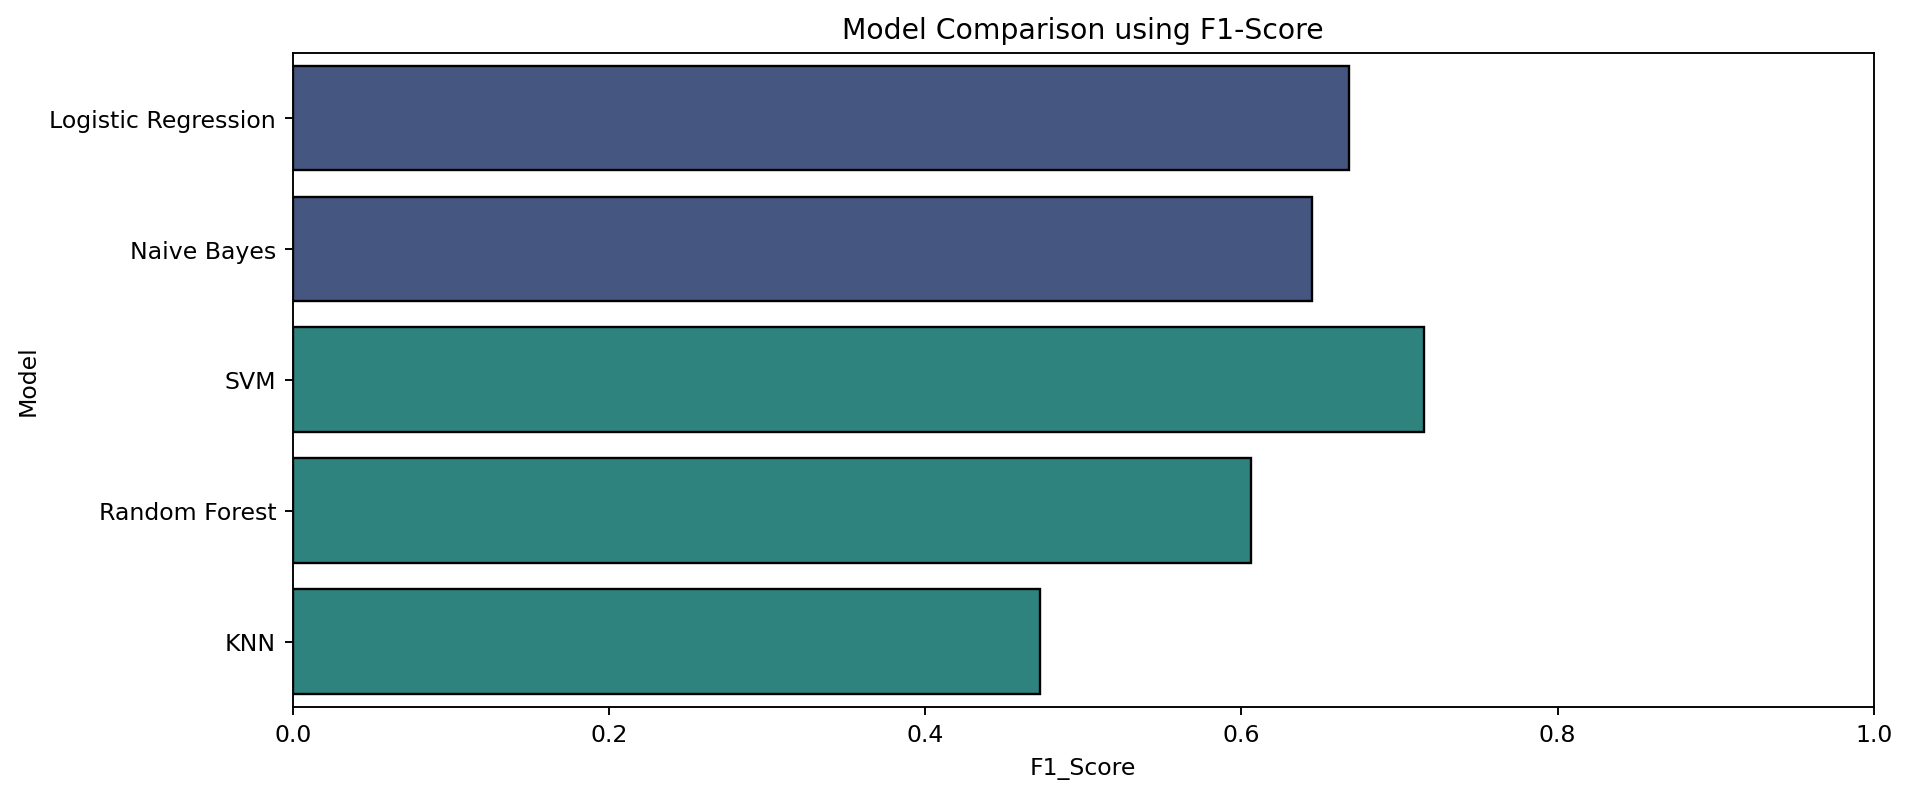

In [280]:
plt.figure(figsize=(12,5), dpi=170)
sns.barplot(x='F1_Score', y='Model', hue=y, data=f1_df, palette='viridis', legend=False, ec='k')
plt.title("Model Comparison using F1-Score")
plt.xlim(0,1)
plt.show()

# FEATURE IMPORTANCE VISUALIZATION

🔹 Extract Feature Names

In [245]:
feature_names = tfidf.get_feature_names_out()

🔹 Get Coefficients

In [247]:
coefficients = best_lr.coef_

## 🔹 Create Feature Importance DataFrame (Example: Negative Sentiment)

In [251]:
import numpy as np

neg_class_index = list(best_lr.classes_).index('negative')

top_negative_features = pd.DataFrame({
    'Word': feature_names,
    'Coefficient': coefficients[neg_class_index]
}).sort_values(by='Coefficient', ascending=False).head(15)

top_negative_features

,Word,Coefficient
293,dont,4.001216
623,lost,3.260664
272,depressed,3.144885
668,mine,3.017285
1003,suck,2.962674
1166,well,2.891461
975,sorry,2.852370
674,missed,2.730620
519,im,2.664853
431,gloomy,2.597040


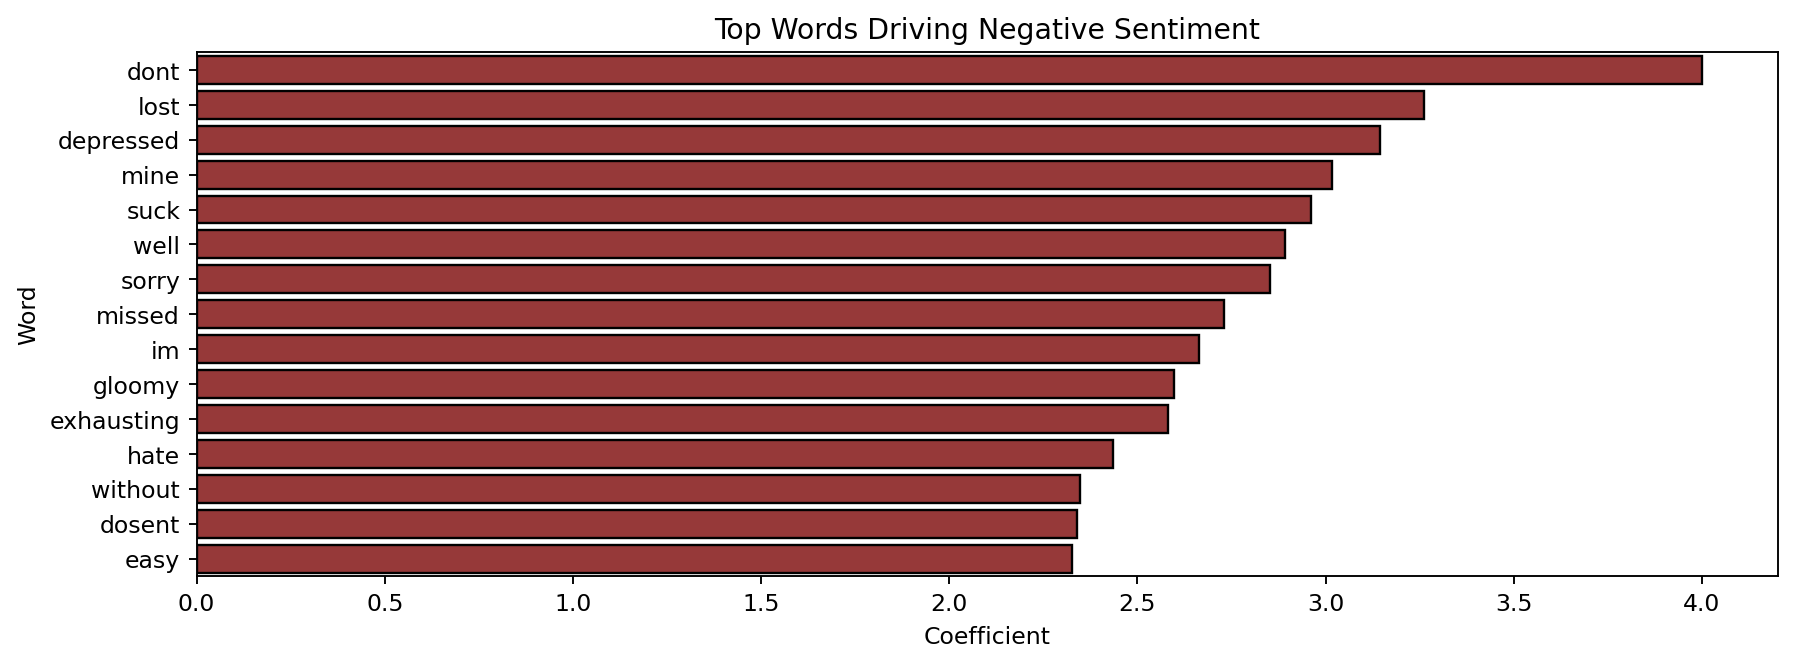

In [298]:
plt.figure(figsize=(12,4), dpi=170)
sns.barplot(x='Coefficient', y='Word', data=top_negative_features, color='brown', ec='k')
plt.title("Top Words Driving Negative Sentiment")
plt.show()

## 🔹 Positive Sentiment Feature Importance

In [255]:
pos_class_index = list(best_lr.classes_).index('positive')

top_positive_features = pd.DataFrame({
    'Word': feature_names,
    'Coefficient': coefficients[pos_class_index]
}).sort_values(by='Coefficient', ascending=False).head(15)

top_positive_features

,Word,Coefficient
626,love,5.034696
464,happy,4.287293
35,amazing,4.278370
723,nice,3.834157
418,funny,3.213039
850,really,3.203412
448,great,3.010631
438,good,2.840609
1054,thinking,2.632809
73,awesome,2.575529


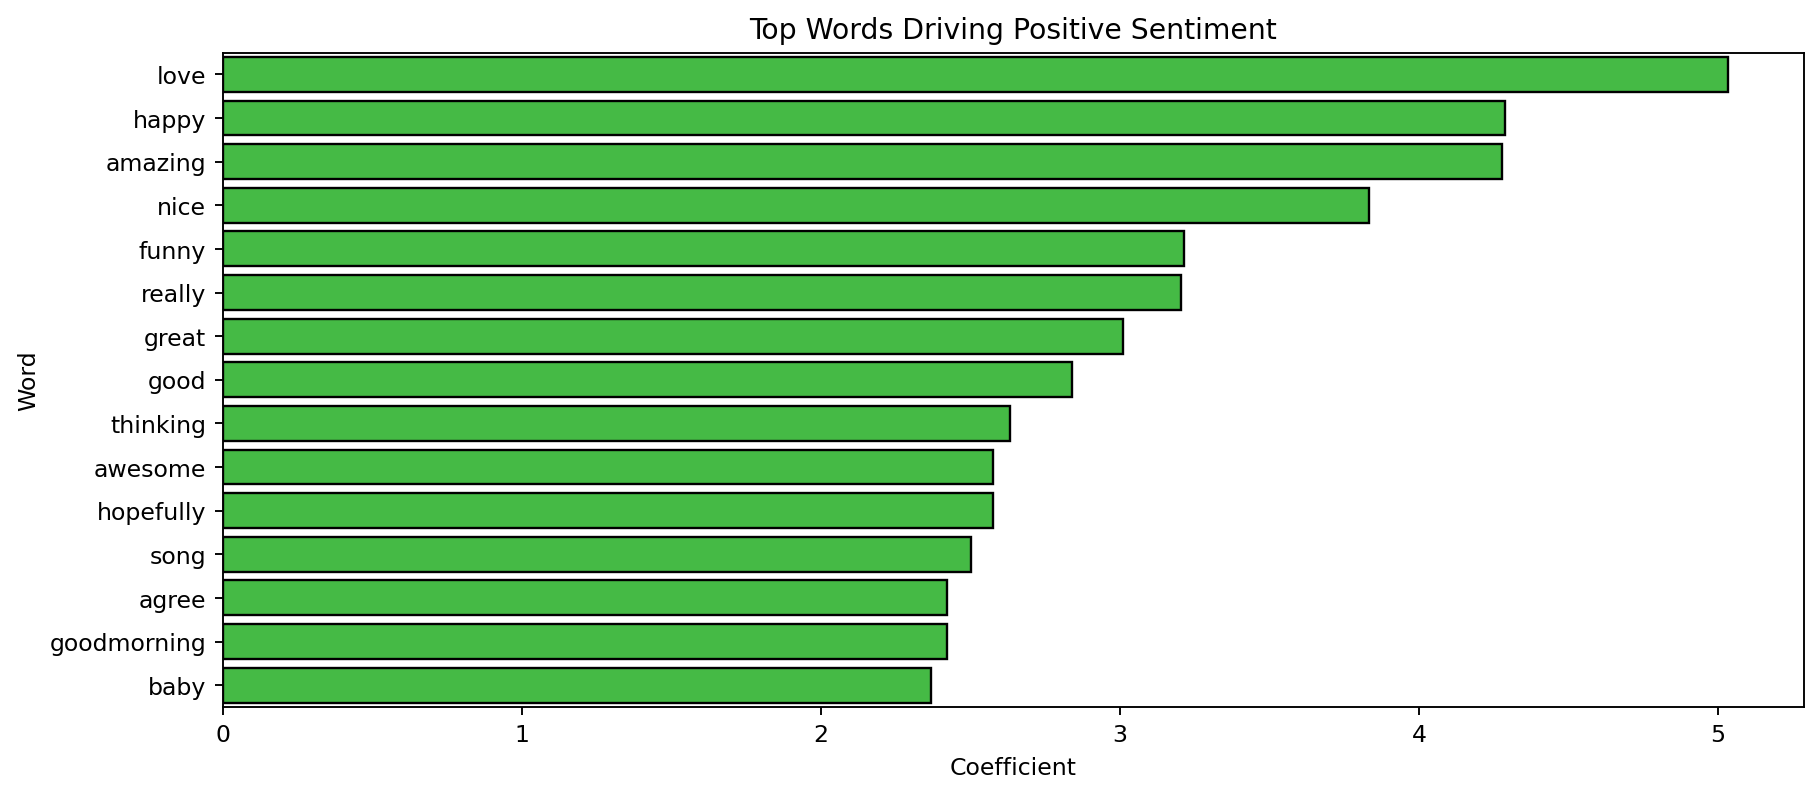

In [300]:
plt.figure(figsize=(12,5),dpi=170)
sns.barplot(x='Coefficient', y='Word', data=top_positive_features, color='limegreen', ec='k')
plt.title("Top Words Driving Positive Sentiment")
plt.show()

In [306]:
import pickle
from sklearn.pipeline import Pipeline

sentiment_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("svm", svm_model)
])

with open("sentiment_analysis.pkl", "wb") as f:
    pickle.dump(sentiment_pipeline, f)

print("Sentiment analysis model saved successfully!")

Sentiment analysis model saved successfully!


In [316]:
sample_text = ["The food is good and environment is really well"]

prediction = sentiment_pipeline.predict(sample_text)
print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive
